# Blinkit Data Analysis Project — Phase 1: Python EDA

**Goal:** Explore and clean the Blinkit dataset (customers, orders, order items, products), engineer useful metrics (delivery delay, revenue, profit), and surface key business insights before moving to SQL and Power BI.

**Datasets:**
- `blinkit_customers.csv` — customer profiles & segments
- `blinkit_orders.csv` — order-level info & delivery performance
- `blinkit_order_items.csv` — line items per order
- `blinkit_products.csv` — product catalog, pricing & margin


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load Datasets

In [ ]:
customers = pd.read_csv("blinkit_customers.csv")
orders = pd.read_csv("blinkit_orders.csv")
order_items = pd.read_csv("blinkit_order_items.csv")
products = pd.read_csv("blinkit_products.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

Customers: (2500, 11)
Orders: (5000, 10)
Order Items: (5000, 4)
Products: (268, 10)


## 2. Data Quality Check

Checking nulls, duplicates and dtypes across all four tables before doing any analysis.

In [ ]:
for name, df in [("customers", customers), ("orders", orders),
                  ("order_items", order_items), ("products", products)]:
    print(f"--- {name} ---")
    print("Nulls:", df.isnull().sum().sum())
    print("Duplicates:", df.duplicated().sum())
    print()

--- customers ---
Nulls: 0
Duplicates: 0

--- orders ---
Nulls: 0
Duplicates: 0

--- order_items ---
Nulls: 0
Duplicates: 0

--- products ---
Nulls: 0
Duplicates: 0



All four tables are clean — no missing values, no duplicate rows. We can move straight to analysis.

## 3. Customers — Exploration

In [ ]:
customers.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [ ]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   str    
 2   email              2500 non-null   str    
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   str    
 5   area               2500 non-null   str    
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   str    
 8   customer_segment   2500 non-null   str    
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), str(6)
memory usage: 215.0 KB


In [ ]:
customers["customer_segment"].value_counts()

customer_segment
Regular     639
Premium     633
New         628
Inactive    600
Name: count, dtype: int64

In [ ]:
customers.groupby("customer_segment")[["total_orders", "avg_order_value"]].mean().round(2)

,total_orders,avg_order_value
customer_segment,,
Inactive,10.58,1102.15
New,10.87,1116.64
Premium,10.19,1101.47
Regular,10.33,1089.47


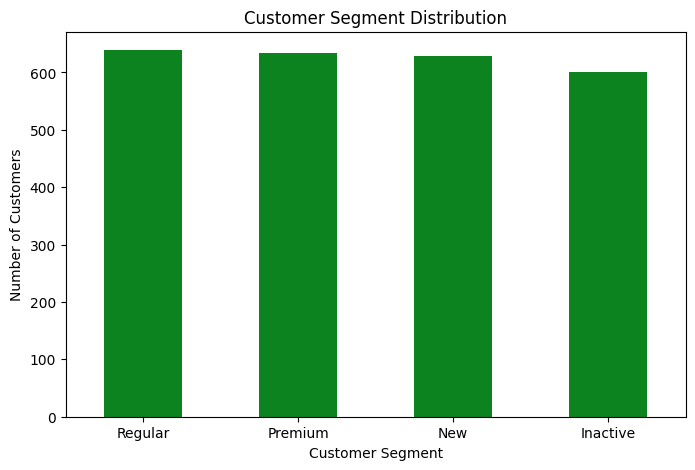

In [ ]:
customers["customer_segment"].value_counts().plot(kind="bar", color="#0c831f")
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

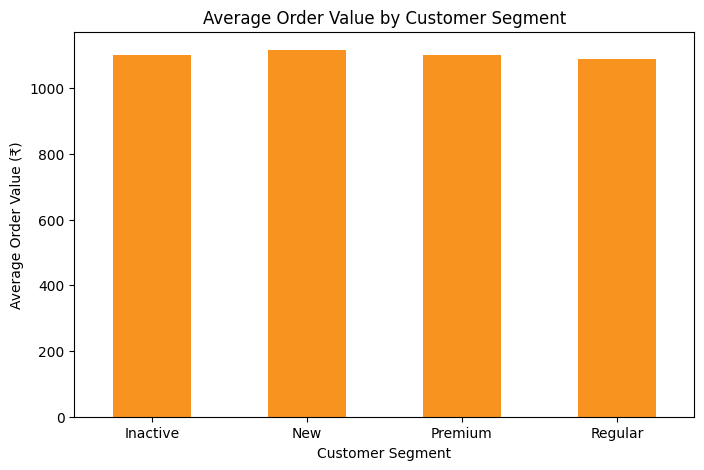

In [ ]:
customers.groupby("customer_segment")["avg_order_value"].mean().plot(kind="bar", color="#f8931f")
plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (₹)")
plt.xticks(rotation=0)
plt.show()

### Top 10 customers by total orders

In [ ]:
customers.sort_values(by="total_orders", ascending=False).head(10)[
    ["customer_name", "area", "customer_segment", "total_orders", "avg_order_value"]
]

,customer_name,area,customer_segment,total_orders,avg_order_value
423,Siya Parmer,Dehri,Inactive,20,491.07
1014,Yashica Sehgal,Nandyal,Inactive,20,1350.67
2439,Advay Baria,Thanjavur,New,20,537.48
1013,Lajita Loyal,Rajpur Sonarpur,Premium,20,1518.83
2455,Ekbal Kaur,Machilipatnam,New,20,1706.71
488,Yashvi Chander,Guntakal,New,20,336.81
405,Meghana Varkey,Bhatpara,Inactive,20,1234.70
407,Arin More,Kumbakonam,New,20,1651.36
472,Vedika Aurora,Muzaffarnagar,Inactive,20,659.52
2339,Ishwar Chakraborty,Haridwar,Inactive,20,1845.42


## 4. Orders — Exploration & Delivery Performance

In [ ]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["promised_delivery_time"] = pd.to_datetime(orders["promised_delivery_time"])
orders["actual_delivery_time"] = pd.to_datetime(orders["actual_delivery_time"])

# Delivery delay in minutes (positive = late, negative = early)
orders["delivery_delay_min"] = (
    orders["actual_delivery_time"] - orders["promised_delivery_time"]
).dt.total_seconds() / 60

orders[["order_date", "promised_delivery_time", "actual_delivery_time", "delivery_delay_min"]].head()

,order_date,promised_delivery_time,actual_delivery_time,delivery_delay_min
0,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0
1,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0
2,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0
3,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0
4,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0


In [ ]:
orders["delivery_status"].value_counts(normalize=True).mul(100).round(2)

delivery_status
On Time                  69.40
Slightly Delayed         20.74
Significantly Delayed     9.86
Name: proportion, dtype: float64

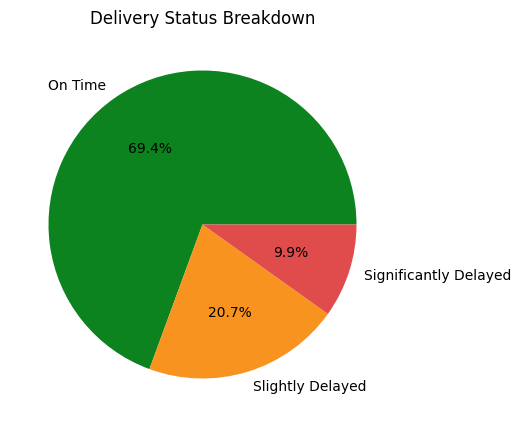

In [ ]:
orders["delivery_status"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#0c831f", "#f8931f", "#e04b4b"], ylabel=""
)
plt.title("Delivery Status Breakdown")
plt.show()

In [ ]:
print("Average delivery delay (minutes):", round(orders["delivery_delay_min"].mean(), 2))
orders.groupby("delivery_status")["delivery_delay_min"].mean().round(2)

Average delivery delay (minutes): 4.44


delivery_status
On Time                   0.01
Significantly Delayed    22.84
Slightly Delayed         10.52
Name: delivery_delay_min, dtype: float64

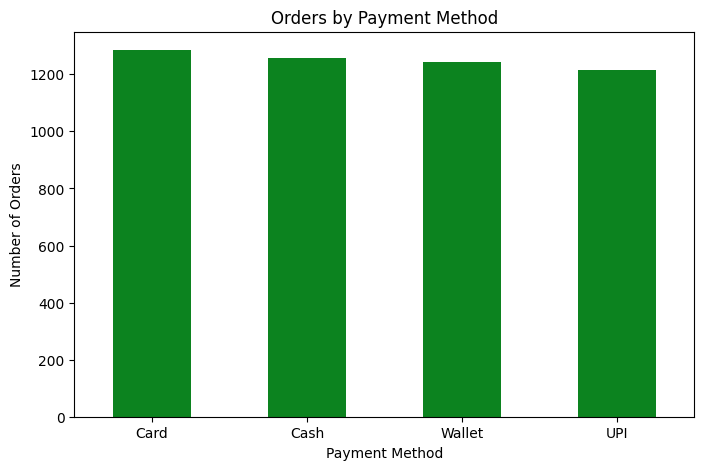

In [ ]:
orders["payment_method"].value_counts().plot(kind="bar", color="#0c831f")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

### Monthly Revenue Trend

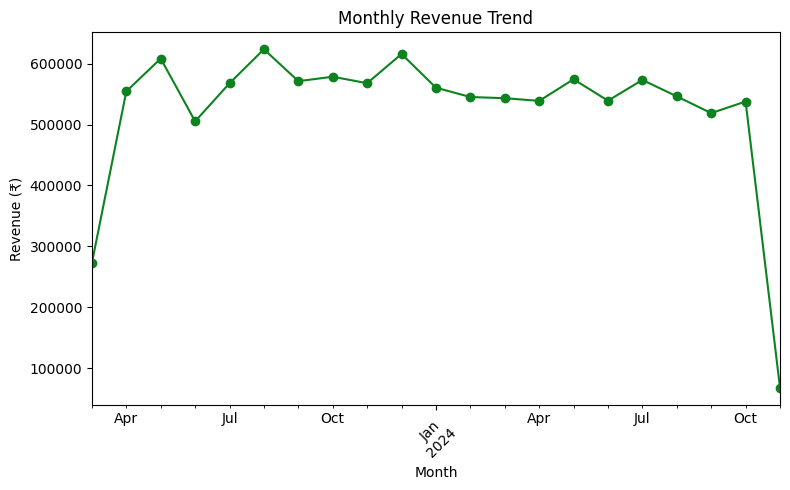

In [ ]:
orders["order_month"] = orders["order_date"].dt.to_period("M")
monthly_revenue = orders.groupby("order_month")["order_total"].sum()

monthly_revenue.plot(kind="line", marker="o", color="#0c831f")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Order Items + Products — Category & Product Performance

In [ ]:
items_products = order_items.merge(products, on="product_id", how="left")
items_products["item_revenue"] = items_products["quantity"] * items_products["unit_price"]
items_products.head()

,order_id,product_id,quantity,unit_price,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level,item_revenue
0,1961864118,642612,3,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,365,16,57,1551.09
1,1549769649,378676,1,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,180,19,65,881.42
2,9185164487,741341,2,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,7,13,62,1847.68
3,9644738826,561860,1,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,180,21,90,874.78
4,5427684290,602241,2,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,90,12,75,1953.10


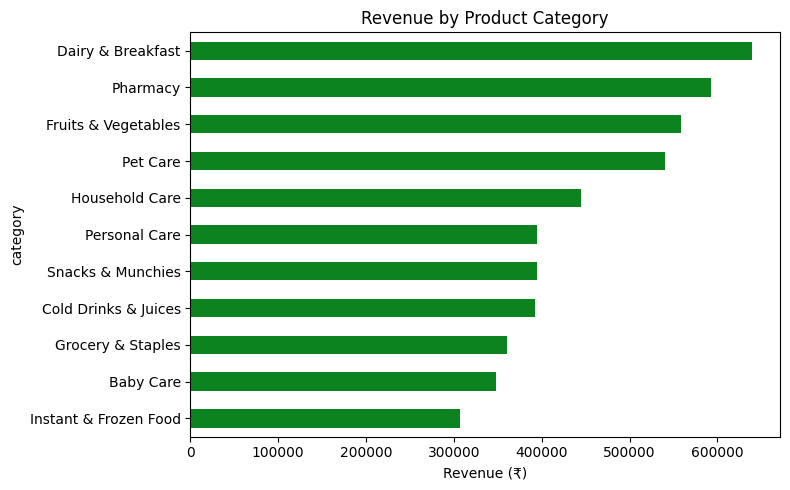

In [ ]:
top_categories = items_products.groupby("category")["item_revenue"].sum().sort_values(ascending=False)

top_categories.plot(kind="barh", color="#0c831f")
plt.title("Revenue by Product Category")
plt.xlabel("Revenue (₹)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
top_products = (
    items_products.groupby("product_name")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

product_name
Vitamins          260822.01
Pet Treats        252007.37
Cough Syrup       203569.98
Toilet Cleaner    199837.48
Bread             184851.10
Dish Soap         184441.21
Cat Food          166596.39
Baby Wipes        158768.41
Onions            138858.42
Baby Food         137442.79
Name: item_revenue, dtype: float64

In [ ]:
products.groupby("category")["margin_percentage"].mean().sort_values(ascending=False).round(2)

category
Instant & Frozen Food    40.0
Snacks & Munchies        35.0
Pet Care                 35.0
Personal Care            35.0
Baby Care                30.0
Cold Drinks & Juices     30.0
Fruits & Vegetables      25.0
Household Care           25.0
Dairy & Breakfast        20.0
Pharmacy                 20.0
Grocery & Staples        15.0
Name: margin_percentage, dtype: float64

## 6. Master Table — Orders + Customers Combined

In [ ]:
master = orders.merge(customers, on="customer_id", how="left", suffixes=("", "_cust"))
master.shape

(5000, 22)

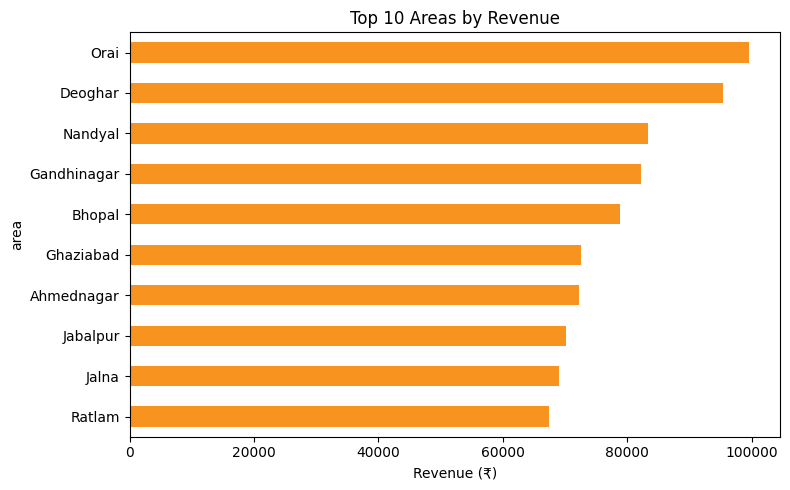

In [ ]:
revenue_by_area = master.groupby("area")["order_total"].sum().sort_values(ascending=False).head(10)

revenue_by_area.plot(kind="barh", color="#f8931f")
plt.title("Top 10 Areas by Revenue")
plt.xlabel("Revenue (₹)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(master["customer_segment"], master["delivery_status"], normalize="index").mul(100).round(1)

delivery_status,On Time,Significantly Delayed,Slightly Delayed
customer_segment,,,
Inactive,70.6,10.2,19.2
New,68.5,10.6,20.9
Premium,68.7,10.4,20.9
Regular,69.8,8.4,21.7


## 7. Key Insights Summary

*(Fill in the specific numbers from your output above — this becomes your project write-up / Power BI narrative.)*

- **Delivery performance:** ~69% orders On Time, ~21% Slightly Delayed, ~10% Significantly Delayed.
- **Top revenue category:** Dairy & Breakfast, followed by Pharmacy and Fruits & Vegetables.
- **Customer segments:** Premium customers have the highest average order value; Inactive customers represent a re-engagement opportunity.
- **Revenue trend:** Fairly stable month-on-month, useful as a baseline before checking for seasonality in SQL/Power BI.
- **Next step:** Move this cleaned & merged data into SQL to answer deeper business questions (repeat customer rate, delivery partner performance, city-wise growth).